# Task 5: RLVR versus RLAIF

The experiment pipeline is implemented in `task5_feedback/`. This notebook
validates and inspects saved results on CPU. GPU reproduction is disabled by default.

The three fixed policies are evaluated on the released 300 GSM8K and 100 SVAMP
prompts. The controlled study uses all 100 released diagnostic responses.
The supplied verifier and pairwise judge are unchanged. AI ties include parser
fallbacks; raw judge text is unavailable. Format compliance is measured separately
from verifier correctness. Reproduction instructions are in `task5_feedback/REPRODUCTION.md`.


In [1]:
from pathlib import Path
import os

if Path('task5_feedback').is_dir():
    repo = Path.cwd()
elif (Path.cwd().parent / 'task5_feedback').is_dir():
    repo = Path.cwd().parent
else:
    from google.colab import drive
    drive.mount('/content/drive')
    repo = Path('/content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining')

assert (repo / 'task5_feedback').is_dir(), f'Repository not found: {repo}'
os.chdir(repo)
print('Repository:', repo)
results = Path('results/task5_feedback')


Mounted at /content/drive
Repository: /content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining


In [2]:
import json
import subprocess
import sys

result = subprocess.run(
    [sys.executable, '-m', 'task5_feedback.finalize', '--config', 'configs/feedback.yaml'],
    capture_output=True, text=True,
)
print(result.stdout)
print(result.stderr)
result.check_returncode()
validation = json.loads((results / 'final_artifact_validation.json').read_text())
assert validation['passed']
print('PASS: full saved-artifact validation.')


{
  "passed": true,
  "num_policy_responses": 1200,
  "num_policy_pairs": 1200,
  "num_diagnostic_responses": 100,
  "num_diagnostic_pairs": 200,
  "checks": [
    "recorded source and dataset hashes",
    "fixed policy and decoding configuration",
    "ordered prompts and diagnostic groups",
    "response hashes and verifier recomputation",
    "pairwise cache binding",
    "all seven CSV and JSON tables recomputed"
  ],
  "limitations": [
    "TIE includes unparsed judge outputs; raw judge text was not saved.",
    "One hash-selected A/B orientation is used per pair.",
    "CPU validation checks recorded adapter hashes, without requiring adapter weights.",
    "Different evaluation datasets prevent causal interpretation of transfer differences."
  ]
}


PASS: full saved-artifact validation.


In [3]:
import pandas as pd
from IPython.display import display

for name in ['math_comparison', 'verifier_judge_agreement', 'transfer_drops', 'pair_diagnostics']:
    print(name)
    display(pd.read_csv(results / f'{name}.csv'))


math_comparison


,dataset,policy,num_prompts,exact_accuracy,format_compliance,response_length_mean,generation_cap_rate,ai_pairwise_score_vs_sft,ai_group_win_rate
0,gsm,sft,300,0.273333,0.196667,273.923333,0.020000,0.500000,0.494167
1,gsm,rlvr,300,0.300000,0.203333,274.506667,0.020000,0.505000,0.500000
2,gsm,rlaif,300,0.280000,0.203333,274.596667,0.023333,0.506667,0.505833
3,transfer,sft,100,0.440000,0.380000,163.810000,0.000000,0.500000,0.520000
4,transfer,rlvr,100,0.450000,0.390000,163.090000,0.000000,0.480000,0.500000
5,transfer,rlaif,100,0.420000,0.370000,165.870000,0.000000,0.480000,0.480000


verifier_judge_agreement


,dataset,policy_a,policy_b,num_pairs,a_preferred_rate,tie_rate,b_preferred_rate,verifier_judge_agreement_all,verifier_decisive_pairs,verifier_judge_agreement_on_verifier_decisive,verifier_tie_rate
0,gsm,sft,rlvr,300,0.016667,0.956667,0.026667,0.936667,12,0.250,0.960000
1,gsm,sft,rlaif,300,0.010000,0.966667,0.023333,0.946667,8,0.125,0.973333
2,gsm,rlvr,rlaif,300,0.010000,0.970000,0.020000,0.930000,12,0.000,0.960000
3,transfer,sft,rlvr,100,0.130000,0.780000,0.090000,0.750000,5,0.000,0.950000
4,transfer,sft,rlaif,100,0.140000,0.760000,0.100000,0.750000,4,0.250,0.960000
5,transfer,rlvr,rlaif,100,0.130000,0.780000,0.090000,0.750000,5,0.200,0.950000


transfer_drops


,policy,exact_accuracy_gsm_minus_transfer,format_compliance_gsm_minus_transfer,ai_pairwise_score_vs_sft_gsm_minus_transfer,response_length_mean_gsm_minus_transfer
0,sft,-0.166667,-0.183333,0.000000,110.113333
1,rlvr,-0.150000,-0.186667,0.025000,111.416667
2,rlaif,-0.140000,-0.166667,0.026667,108.726667


pair_diagnostics


,comparison_set,num_pairs,identical_response_pairs,ai_decisive_on_identical,ai_ties,verifier_ties,unparsed_judge_count
0,gsm,900,720,20,868,868,NaN
1,transfer,300,266,57,232,286,NaN
2,controlled,200,0,0,173,80,NaN


In [4]:
for name in ['diagnostic_variants', 'controlled_pairs', 'reward_sensitivity', 'failure_types']:
    print(name)
    display(pd.read_csv(results / f'{name}.csv'))


diagnostic_variants


,variant_type,num_responses,exact_reward_mean,ai_group_win_rate_mean
0,clean_correct,20,1.0,0.5000
1,corrupt_reasoning_correct_final,20,1.0,0.5000
2,good_reasoning_wrong_final,20,0.0,0.4750
3,persuasive_filler_correct,20,1.0,0.5875
4,gold_distractor_wrong_final,20,0.0,0.4375


controlled_pairs


,perturbation,mechanism,num_pairs,clean_preferred_rate,tie_rate,perturbed_preferred_rate,better_response_rate,wrong_preference_rate,expected_relation
0,corrupt_reasoning_correct_final,exact_verifier,20,0.00,1.00,0.00,0.00,0.0,clean diagnostically better
1,corrupt_reasoning_correct_final,ai_pairwise,20,0.00,1.00,0.00,0.00,0.0,clean diagnostically better
2,good_reasoning_wrong_final,exact_verifier,20,1.00,0.00,0.00,1.00,0.0,clean diagnostically better
3,good_reasoning_wrong_final,ai_pairwise,20,0.00,1.00,0.00,0.00,0.0,clean diagnostically better
4,persuasive_filler_correct,exact_verifier,20,0.00,1.00,0.00,NaN,NaN,equivalent mathematical content; report style ...
5,persuasive_filler_correct,ai_pairwise,20,0.00,0.75,0.25,NaN,NaN,equivalent mathematical content; report style ...
6,gold_distractor_wrong_final,exact_verifier,20,1.00,0.00,0.00,1.00,0.0,clean diagnostically better
7,gold_distractor_wrong_final,ai_pairwise,20,0.25,0.75,0.00,0.25,0.0,clean diagnostically better


reward_sensitivity


,mechanism,S_reason,reason_tie_rate,reason_wrong_preference_rate,S_outcome,outcome_tie_rate,outcome_wrong_preference_rate,filler_preferred_rate,filler_tie_rate,clean_preferred_over_distractor_rate
0,exact_verifier,0.0,1.0,0.0,1.0,0.0,0.0,0.00,1.00,1.00
1,ai_pairwise,0.0,1.0,0.0,0.0,1.0,0.0,0.25,0.75,0.25


failure_types


,dataset,policy,failure_type,count,rate
0,gsm,sft,missing_designated_final,196,0.653333
1,gsm,sft,correct_terminal_format,49,0.163333
2,gsm,sft,wrong_designated_final,22,0.073333
3,gsm,sft,correct_nonterminal_format,33,0.110000
4,gsm,rlvr,missing_designated_final,188,0.626667
5,gsm,rlvr,correct_terminal_format,53,0.176667
6,gsm,rlvr,wrong_designated_final,22,0.073333
7,gsm,rlvr,correct_nonterminal_format,37,0.123333
8,gsm,rlaif,missing_designated_final,195,0.650000
9,gsm,rlaif,correct_terminal_format,50,0.166667


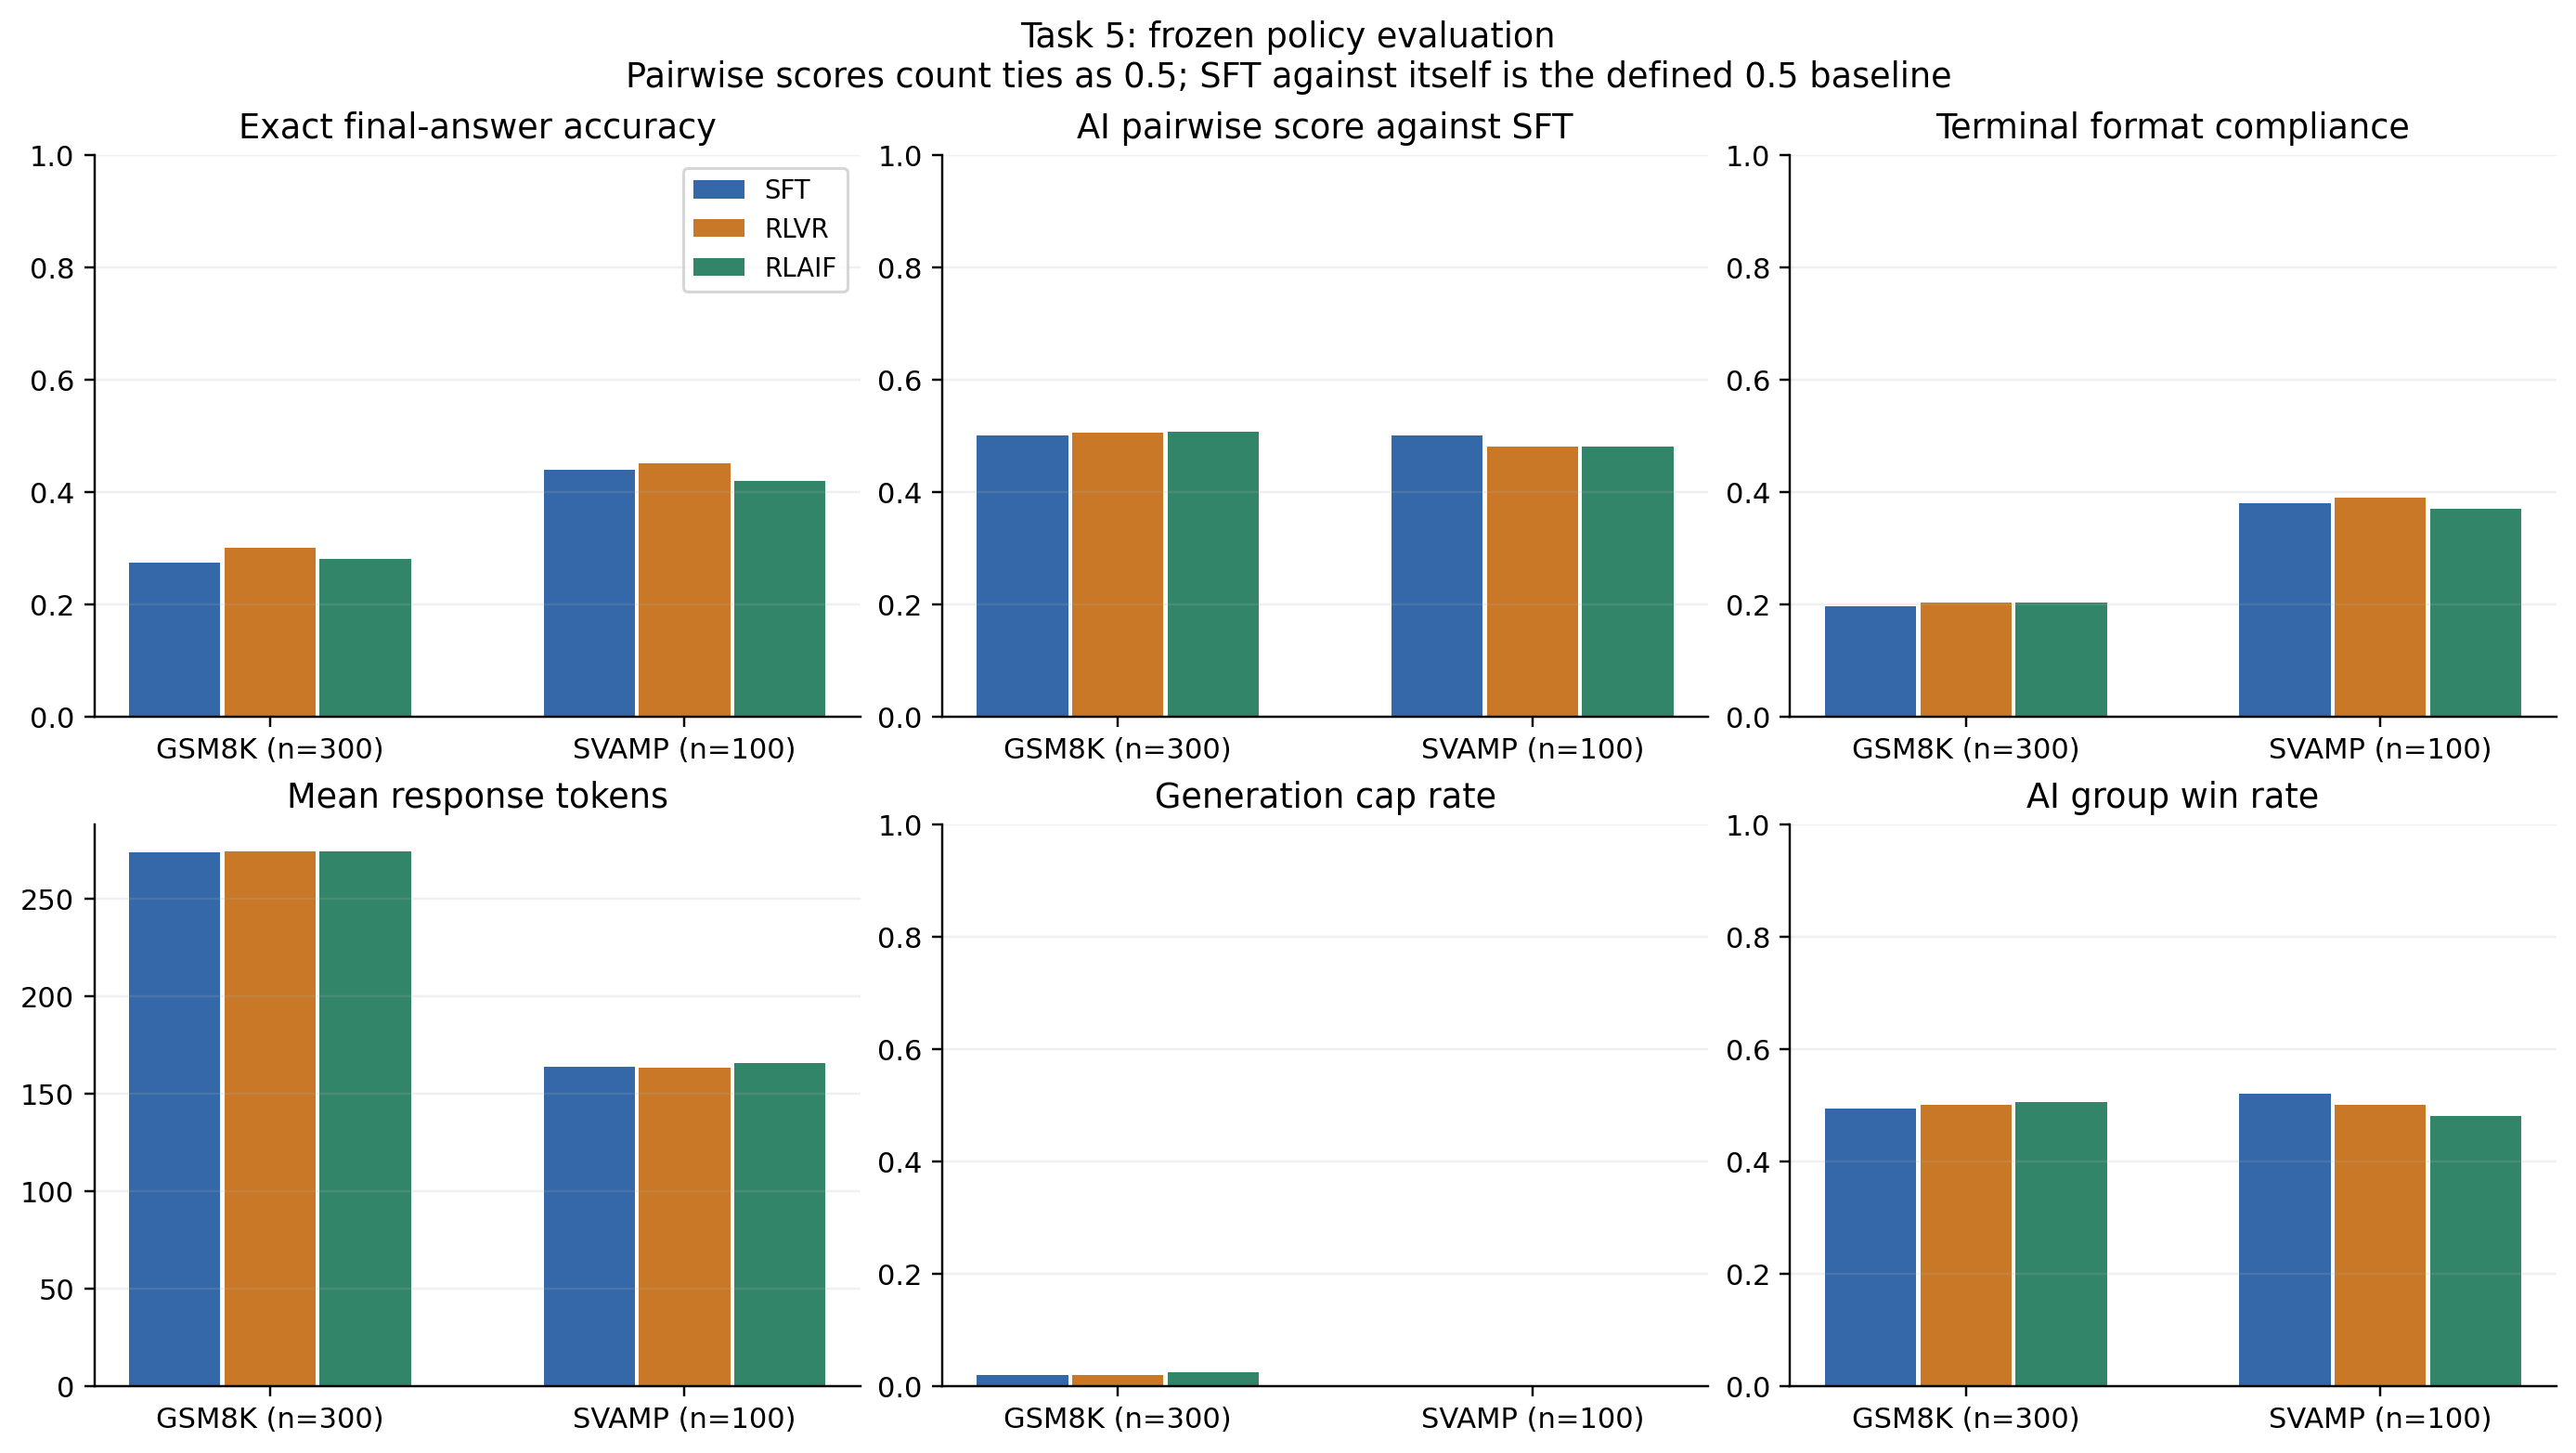

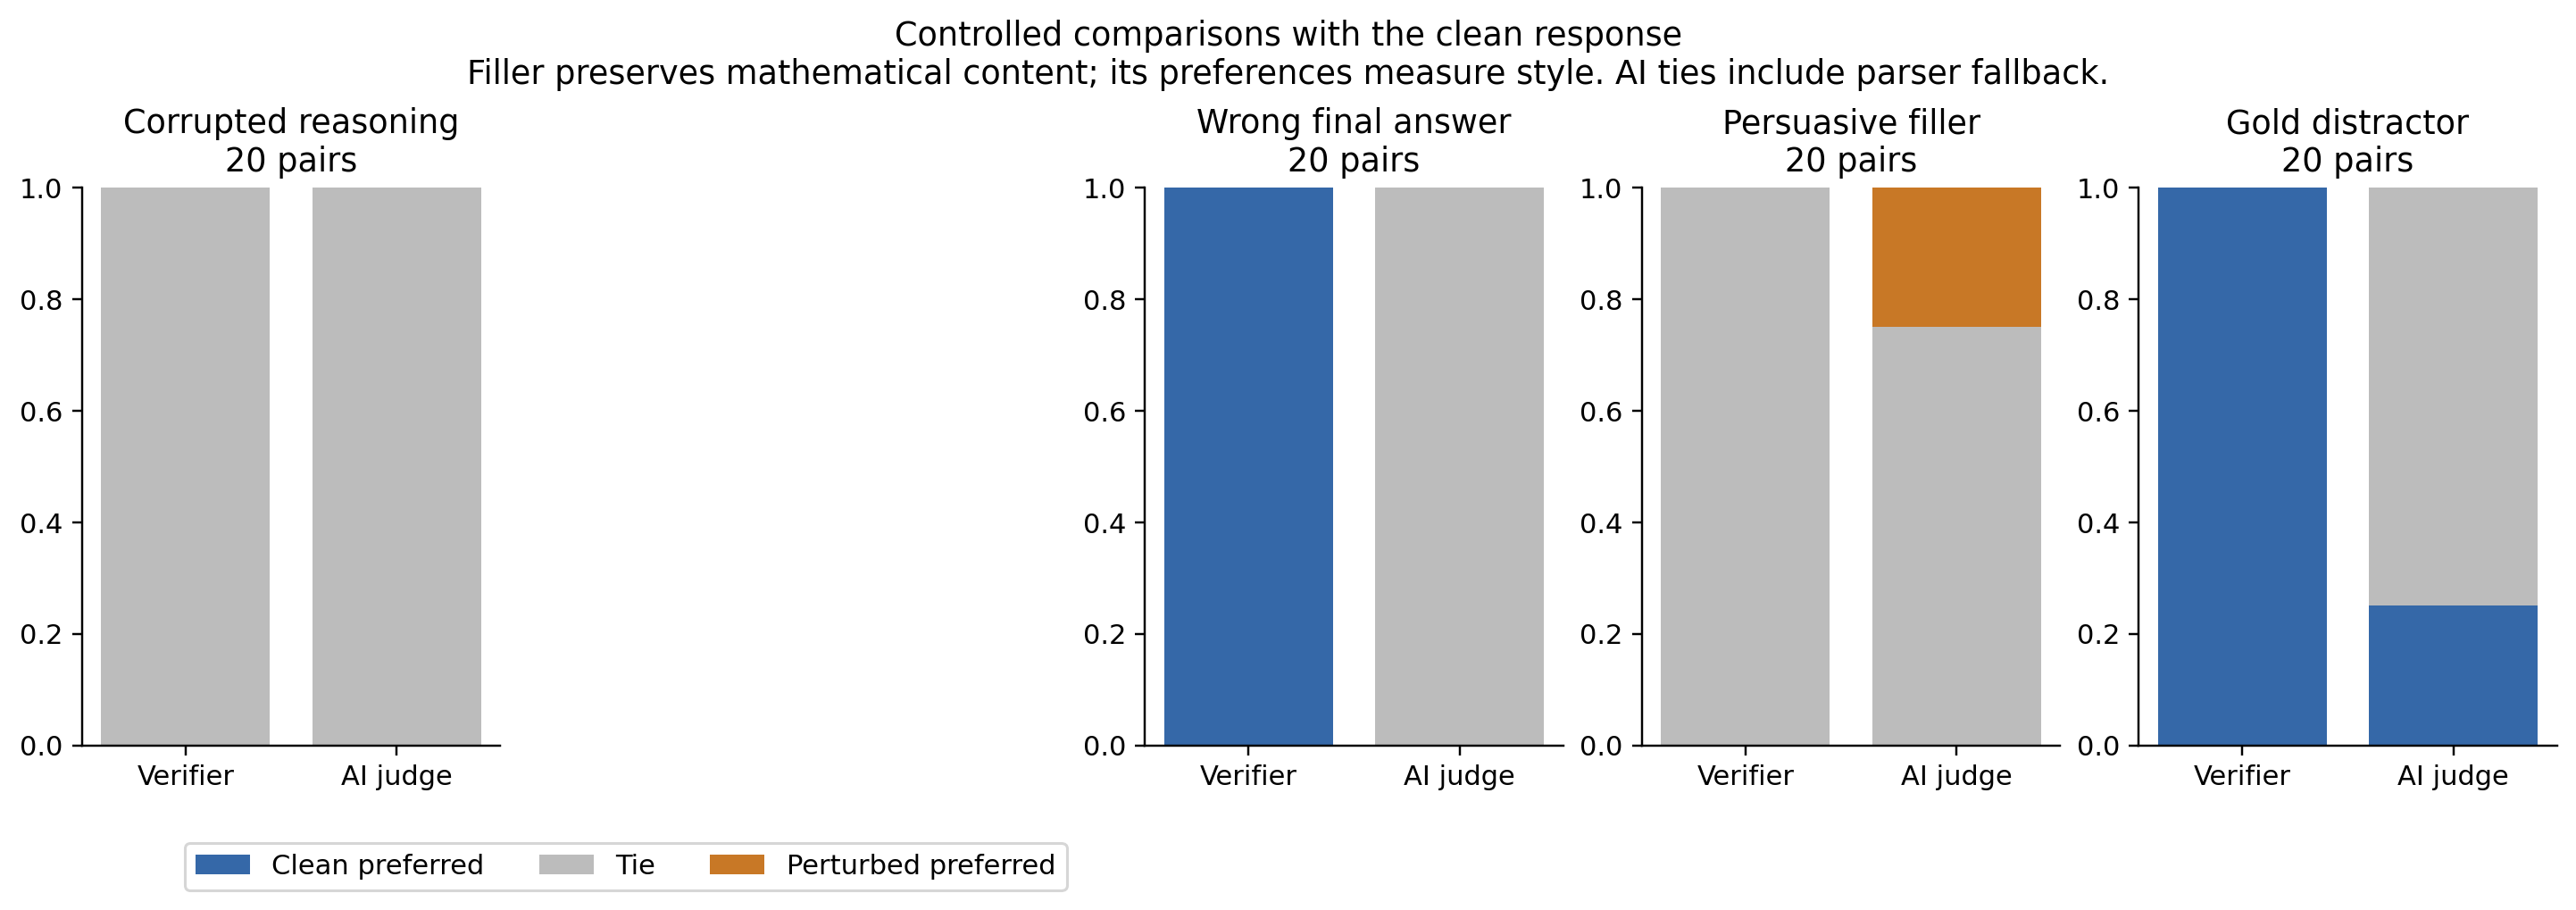

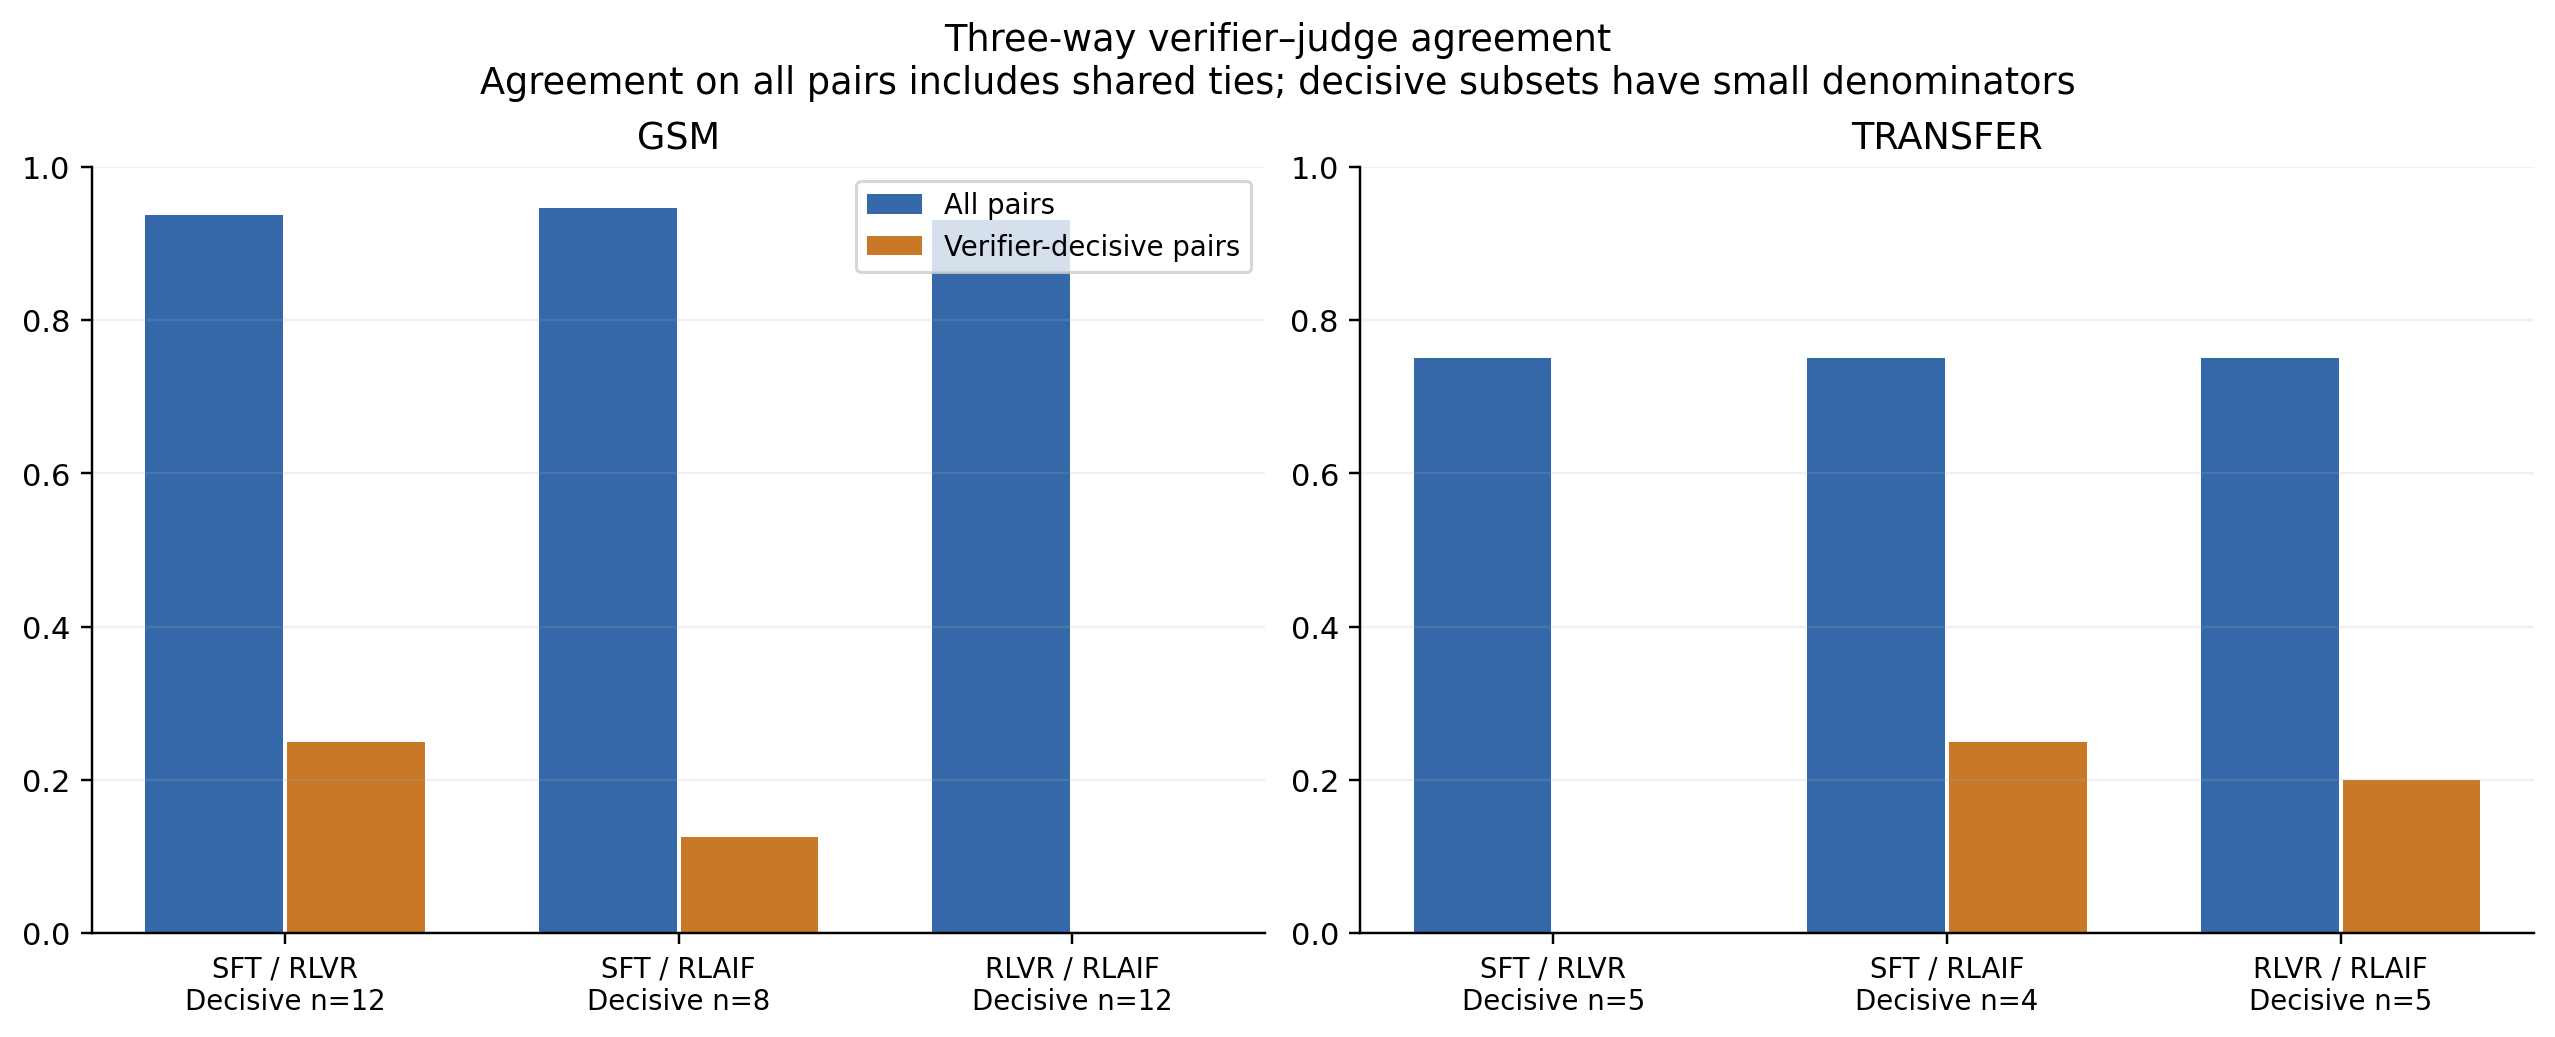

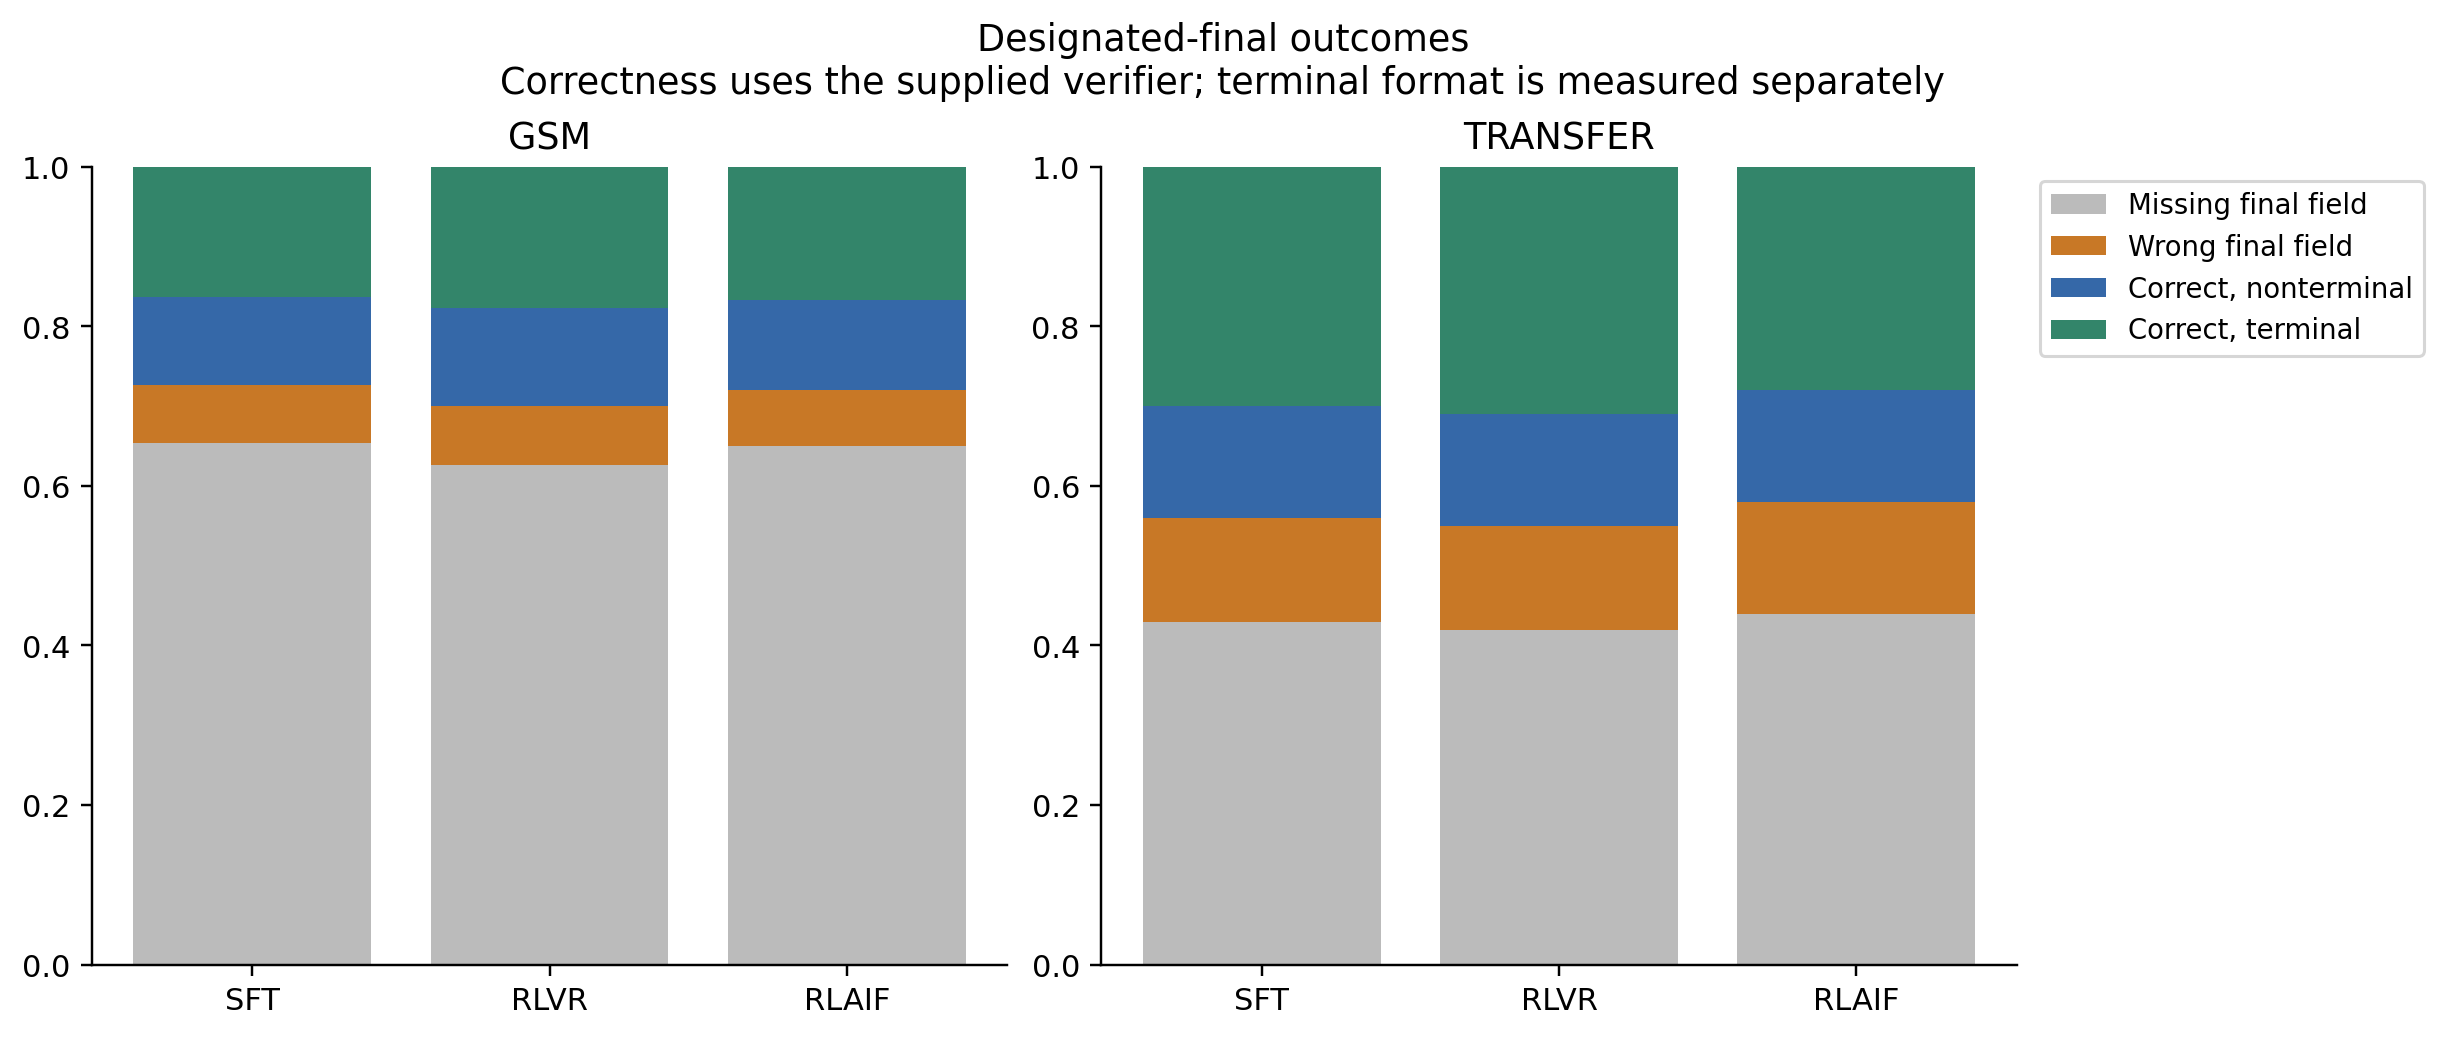

In [5]:
from IPython.display import Image

for name in ['task5_policy_comparison', 'task5_controlled_pairs',
             'task5_verifier_judge_agreement', 'task5_failure_types']:
    display(Image(filename=f'report/figures/{name}.png'))


In [6]:
candidates = json.loads((results / 'qualitative_candidates.json').read_text())
for item in candidates:
    print('\n' + '=' * 70)
    print(item['perturbation'], '| problem:', item['problem_id'])
    print('Question:', item['question'])
    print('Gold final:', item['gold_final'])
    print('\nClean response:\n' + item['clean_response'])
    print('\nPerturbed response:\n' + item['perturbed_response'])
    print('\nVerifier:', item['verifier_preference'], '| AI judge:', item['ai_preference'])



corrupt_reasoning_correct_final | problem: 803
Question: Kris is trying to earn a video game achievement for playing a total of 30 hours. If Kris plays for half an hour every day for 2 weeks then plays for 2 hours every day for a week, how many hours does she still need to play to earn the achievement?
Gold final: 9

Clean response:
Two weeks is the same as 2 weeks * 7 days = <<2*7=14>>14 days.
So playing for half an hour every day means Kris will have played for 0.5 hours * 14 days = <<0.5*14=7>>7 hours.
Playing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours.
She therefore still needs to play 30 – 7 – 14 = <<30-7-14=9>>9 hours.
#### 9

Perturbed response:
Two weeks is the same as 2 weeks * 7 days = <<2*7=15>>14 days.
So playing for half an hour every day means Kris will have played for 0.5 hours * 14 days = <<0.5*14=7>>7 hours.
Playing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours

## GPU reproduction

For a fresh reproduction, install the pinned requirements and run
`python -m scripts.download_assets` and `python -m scripts.validate_assets` first.
Use an A100 runtime and the supplied adapters. The cell below uses a separate
output directory and keeps the same batch size of 16. Existing matching runs
can resume; changed metadata is rejected. Returning to CPU inspection does not
require regenerating responses. See `REPRODUCTION.md` for environment details.


In [7]:
RUN_GPU = False

if RUN_GPU:
    import torch
    assert torch.cuda.is_available(), 'Select an A100 GPU runtime.'
    assert 'A100' in torch.cuda.get_device_name(0)
    commands = [
        [sys.executable, '-m', 'task5_feedback.validate_pipeline'],
        [sys.executable, '-u', '-m', 'task5_feedback.pipeline',
         '--config', 'configs/feedback.yaml', '--stage', 'all', '--batch-size', '16',
         '--output', 'results/task5_feedback_reproduction'],
        [sys.executable, '-m', 'task5_feedback.finalize',
         '--config', 'configs/feedback.yaml', '--output', 'results/task5_feedback_reproduction',
         '--figures', 'report/reproduction_figures'],
    ]
    for command in commands:
        print('Running:', ' '.join(command), flush=True)
        with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                              text=True, bufsize=1) as process:
            for line in process.stdout:
                print(line, end='', flush=True)
            code = process.wait()
        if code:
            raise RuntimeError(f'Command failed: exit code {code}')
else:
    print('GPU reproduction disabled; saved results remain available above.')


GPU reproduction disabled; saved results remain available above.
